# 沐曦 GPU 运行 NV-Generate-MR 说明文档

[NV-Generate-CTMR](https://github.com/NVIDIA-Medtech/NV-Generate-CTMR) 的 `rflow-mr` 模型从随机 latent noise 出发，以体素间距和 MRI 模态类别为条件，生成单通道三维合成 MRI 并保存为 NIfTI；模型卡见 [nvidia/NV-Generate-MR](https://huggingface.co/nvidia/NV-Generate-MR)。

本教程在沐曦 GPU 上复现一次 `mri_t2` 生成，并在同一 Notebook 中完成运行参数设置、上游 API 调用、NIfTI 工程检查和 axial/coronal/sagittal 三正交切片展示。

上游源代码采用 Apache License 2.0，全文见同目录 `LICENSE`。模型权重采用 NVIDIA License，请自行下载，许可证全文见 `LICENSE.weights`。本教程仅用于研究、评估和工程验证，不用于诊断、治疗、分诊、临床决策、患者服务或监管提交。

## 1. 安装

以下命令仅供操作者在 Notebook 外准备环境；Markdown 单元不会自动执行安装或修改环境。

### 1.1 沐曦容器

启动包含 MACA PyTorch 的基础镜像，并挂载上游源码、模型目录和输出目录：

```bash
docker run -it --name nv-generate-mr-notebook \
  --device=/dev/mxcd --device=/dev/dri \
  --group-add video --network none \
  --shm-size=16G --ulimit memlock=-1 --ulimit stack=67108864 \
  -v /path/to/NV-Generate-CTMR:/workspace/NV-Generate-CTMR:ro \
  -v /path/to/NV-Generate-MR:/workspace/models/NV-Generate-MR:ro \
  -v /path/to/output:/workspace/output \
  <MACA_PYTORCH_IMAGE> /bin/bash
```

### 1.2 源码、依赖与权重

取得上游源码：

```bash
git clone https://github.com/NVIDIA-Medtech/NV-Generate-CTMR.git \
  /workspace/NV-Generate-CTMR
```

安装其余 Python 包时保留基础镜像中的 MACA PyTorch。以下约束使依赖安装在不替换现有 Torch 的前提下完成：

```bash
MACA_TORCH_ID="$(python -c 'import torch; print(torch.__version__ + "|" + torch.__file__)')"
python -c 'import torch; print("torch==" + torch.__version__)' \
  > /tmp/maca-torch-constraint.txt

python -m pip install --constraint /tmp/maca-torch-constraint.txt \
  monai==1.5.0 nibabel==5.4.2 numpy==1.26.4 scipy==1.15.3 \
  scikit-image==0.25.2 einops==0.8.2 matplotlib==3.10.8 \
  Pillow==11.3.0 tqdm==4.66.5 fire==0.7.1 tensorboard==2.21.0 \
  PyYAML==6.0.2

test "${MACA_TORCH_ID}" = \
  "$(python -c 'import torch; print(torch.__version__ + "|" + torch.__file__)')"
```

模型权重采用 NVIDIA License，请自行下载。运行前将以下文件放入模型目录：

```text
models/autoencoder_v2.pt
models/diff_unet_3d_rflow-mr.pt
```

Notebook 会在加载前核对所需源码文件和模型资产。

### 1.3 运行参数

以下单元集中设置源码、模型、输出路径以及生成所需的模态、几何和采样参数。默认 shape 与 spacing 对应约 `170 × 170 × 90 mm` 的 FOV。

In [1]:
import os
from pathlib import Path

os.environ.setdefault("CUDA_VISIBLE_DEVICES", "0")
os.environ.setdefault("HF_HUB_OFFLINE", "1")

SOURCE_ROOT = Path(os.environ.get(
    "NV_GENERATE_MR_SOURCE_ROOT", "/workspace/NV-Generate-CTMR"
)).expanduser().resolve()
MODEL_ROOT = Path(os.environ.get(
    "NV_GENERATE_MR_MODEL_ROOT", "/workspace/models/NV-Generate-MR"
)).expanduser().resolve()
OUTPUT_DIR = Path(os.environ.get(
    "NV_GENERATE_MR_OUTPUT_DIR", "/workspace/output/nv-generate-mr"
)).expanduser().resolve()

DEVICE = "cuda:0"
MODALITY = "mri_t2"
MODALITY_CODES = {"mri": 8, "mri_t1": 9, "mri_t2": 10, "mri_flair": 11}
DIM = (256, 256, 128)
SPACING = (170 / 256, 170 / 256, 90 / 128)
RANDOM_SEED = 0
NUM_INFERENCE_STEPS = 30
CFG_GUIDANCE_SCALE = 15
OUTPUT_PREFIX = "nv_generate_mr_mri_t2"
NUM_GPUS = 1

AUTOENCODER_PATH = MODEL_ROOT / "models/autoencoder_v2.pt"
DIFFUSION_PATH = MODEL_ROOT / "models/diff_unet_3d_rflow-mr.pt"
REQUIRED_SOURCE_FILES = (
    "scripts/__init__.py",
    "scripts/diff_model_infer.py",
    "scripts/diff_model_setting.py",
    "scripts/sample.py",
    "scripts/utils.py",
    "configs/environment_maisi_diff_model_rflow-mr.json",
    "configs/config_maisi_diff_model_rflow-mr.json",
    "configs/config_network_rflow.json",
    "configs/modality_mapping.json",
)

FOV_MM = tuple(size * spacing for size, spacing in zip(DIM, SPACING))
print("Source root:", SOURCE_ROOT)
print("Model root:", MODEL_ROOT)
print("Output directory:", OUTPUT_DIR)
print("Device:", DEVICE)
print("Modality:", MODALITY, MODALITY_CODES[MODALITY])
print("Shape:", DIM)
print("Spacing (mm):", tuple(round(v, 6) for v in SPACING))
print("FOV (mm):", tuple(round(v, 3) for v in FOV_MM))
print("Seed / steps / CFG:", RANDOM_SEED, NUM_INFERENCE_STEPS, CFG_GUIDANCE_SCALE)

Source root: /workspace/NV-Generate-CTMR
Model root: /workspace/models/NV-Generate-MR
Output directory: /workspace/notebook/output
Device: cuda:0
Modality: mri_t2 10
Shape: (256, 256, 128)
Spacing (mm): (0.664062, 0.664062, 0.703125)
FOV (mm): (170.0, 170.0, 90.0)
Seed / steps / CFG: 0 30 15


In [2]:
import math

ALLOWED_DIMS = {
    (128, 128, 128),
    (256, 256, 128),
    (384, 384, 128),
    (512, 512, 128),
    (128, 256, 256),
    (256, 128, 256),
    (256, 256, 256),
}
if MODALITY not in MODALITY_CODES:
    raise ValueError(f"不支持的 MRI modality：{MODALITY}")
if DIM not in ALLOWED_DIMS:
    raise ValueError(f"shape 不在 rflow-mr 几何约束内：{DIM}")
if any(not math.isfinite(v) or not 0.4 <= v <= 5.0 for v in SPACING):
    raise ValueError(f"spacing 必须是 [0.4, 5.0] mm 内的有限值：{SPACING}")
if math.prod(DIM) > 512 * 512 * 128:
    raise ValueError("体素总数超过上游约束")
if not 1 <= NUM_INFERENCE_STEPS <= 1000:
    raise ValueError("NUM_INFERENCE_STEPS 必须在 [1, 1000] 内")
if not math.isfinite(CFG_GUIDANCE_SCALE) or CFG_GUIDANCE_SCALE < 0:
    raise ValueError("CFG_GUIDANCE_SCALE 必须是非负有限值")
if NUM_GPUS != 1:
    raise ValueError("本教程只演示单 GPU 生成一个 volume")

print("Parameter checks: PASS")
print("说明：FOV 接近前列腺 T2 训练分布，但不构成器官控制。")


Parameter checks: PASS
说明：FOV 接近前列腺 T2 训练分布，但不构成器官控制。


## 2. 沐曦 GPU 运行效果显示

以下代码验证运行环境、上游入口和本地模型文件，然后执行一次三维 MRI 生成。模型加载、采样、解码与 NIfTI 写盘全部完成后，Notebook 会检查实际输出并显示三正交切片。

本交付环境的推理镜像未包含 Jupyter/IPython，因此保存的输出由一次性 headless runner 在同一 Python 进程、同一全局命名空间中按当前 Notebook 顺序执行全部代码单元并回写；Markdown 单元未执行。该 runner 只负责执行与输出捕获，推理代码完整保留在 Notebook 中。

In [3]:
import hashlib
import json
import sys

import matplotlib
import monai
import nibabel as nib
import numpy as np
import torch


def sha256_file(path, chunk_size=8 * 1024 * 1024):
    digest = hashlib.sha256()
    with path.open("rb") as stream:
        for chunk in iter(lambda: stream.read(chunk_size), b""):
            digest.update(chunk)
    return digest.hexdigest()


if not torch.cuda.is_available():
    raise RuntimeError("未检测到可用 GPU")

for relative_path in REQUIRED_SOURCE_FILES:
    path = SOURCE_ROOT / relative_path
    if not path.is_file() or path.is_symlink():
        raise FileNotFoundError(f"上游文件不存在或不是普通文件：{path}")

for path in (AUTOENCODER_PATH, DIFFUSION_PATH):
    if not path.is_file() or path.is_symlink():
        raise FileNotFoundError(f"模型文件不存在或不是普通文件：{path}")

free_memory, total_memory = torch.cuda.mem_get_info(0)
gpu_name = torch.cuda.get_device_name(0)
print("GPU:", gpu_name)
print(f"GPU memory: {free_memory / 2**30:.1f}/{total_memory / 2**30:.1f} GiB free")
print("Required Python modules: PASS")
print(f"Required upstream files: PASS ({len(REQUIRED_SOURCE_FILES)} files)")
print("Model files:", AUTOENCODER_PATH.name, DIFFUSION_PATH.name)

GPU: MetaX C500
GPU memory: 60.9/63.6 GiB free
Required Python modules: PASS
Required upstream files: PASS (9 files)
Model files: autoencoder_v2.pt diff_unet_3d_rflow-mr.pt


In [4]:
def read_json(path):
    with path.open(encoding="utf-8") as stream:
        return json.load(stream)

base_environment = read_json(
    SOURCE_ROOT / "configs/environment_maisi_diff_model_rflow-mr.json"
)
base_model = read_json(
    SOURCE_ROOT / "configs/config_maisi_diff_model_rflow-mr.json"
)
network_config_path = SOURCE_ROOT / "configs/config_network_rflow.json"
network_config = read_json(network_config_path)
mapping = read_json(SOURCE_ROOT / "configs/modality_mapping.json")

if network_config.get("include_body_region") is not False:
    raise ValueError("当前网络配置不是预期的 image-only rflow-mr")
if mapping.get(MODALITY) != MODALITY_CODES[MODALITY]:
    raise ValueError("modality mapping 与运行参数不一致")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
config_dir = OUTPUT_DIR / "notebook-config"
config_dir.mkdir(parents=True, exist_ok=True)

runtime_environment = dict(base_environment)
runtime_environment.update({
    "data_base_dir": str(SOURCE_ROOT / "data"),
    "embedding_base_dir": str(SOURCE_ROOT / "embeddings"),
    "json_data_list": str(SOURCE_ROOT / "dataset.json"),
    "model_dir": str(DIFFUSION_PATH.parent),
    "model_filename": DIFFUSION_PATH.name,
    "output_dir": str(OUTPUT_DIR),
    "output_prefix": OUTPUT_PREFIX,
    "trained_autoencoder_path": str(AUTOENCODER_PATH),
    "existing_ckpt_filepath": str(DIFFUSION_PATH),
    "modality_mapping_path": str(SOURCE_ROOT / "configs/modality_mapping.json"),
})
runtime_model = dict(base_model)
runtime_model["diffusion_unet_inference"] = dict(base_model["diffusion_unet_inference"])
runtime_model["diffusion_unet_inference"].update({
    "dim": list(DIM),
    "spacing": list(SPACING),
    "random_seed": RANDOM_SEED,
    "num_inference_steps": NUM_INFERENCE_STEPS,
    "modality": MODALITY_CODES[MODALITY],
    "cfg_guidance_scale": CFG_GUIDANCE_SCALE,
})

ENV_CONFIG_PATH = config_dir / "environment.json"
MODEL_CONFIG_PATH = config_dir / "model.json"
for path, payload in (
    (ENV_CONFIG_PATH, runtime_environment),
    (MODEL_CONFIG_PATH, runtime_model),
):
    with path.open("w", encoding="utf-8") as stream:
        json.dump(payload, stream, ensure_ascii=False, indent=2)

print("Environment config:", ENV_CONFIG_PATH)
print("Model config:", MODEL_CONFIG_PATH)
print("Network config:", network_config_path)
print("Body-region conditioning enabled:", network_config["include_body_region"])


Environment config: /workspace/notebook/output/notebook-config/environment.json
Model config: /workspace/notebook/output/notebook-config/model.json
Network config: /workspace/NV-Generate-CTMR/configs/config_network_rflow.json
Body-region conditioning enabled: False


### 2.1 实际生成

计时范围包含配置解析、模型加载、随机噪声创建、Rectified Flow 去噪、VAE decode 和 NIfTI 写盘，不包含前面的环境检查和后面的结果验证。计时前后均同步设备。

In [5]:
import time

source_root_text = str(SOURCE_ROOT)
if source_root_text not in sys.path:
    sys.path.insert(0, source_root_text)

from scripts.diff_model_infer import diff_model_infer

torch.cuda.synchronize()
torch.cuda.reset_peak_memory_stats()
started = time.perf_counter()
generated_paths = diff_model_infer(
    env_config_path=str(ENV_CONFIG_PATH),
    model_config_path=str(MODEL_CONFIG_PATH),
    model_def_path=str(network_config_path),
    num_gpus=NUM_GPUS,
)
torch.cuda.synchronize()
inference_seconds = time.perf_counter() - started
peak_memory_gib = torch.cuda.max_memory_allocated(0) / 2**30

if not generated_paths or len(generated_paths) != 1:
    raise RuntimeError(f"预期单 GPU 返回一个 NIfTI，实际为：{generated_paths}")
GENERATED_PATH = Path(generated_paths[0]).resolve()
if not GENERATED_PATH.is_file() or GENERATED_PATH.is_symlink():
    raise FileNotFoundError(f"生成结果不存在或不是普通文件：{GENERATED_PATH}")
if GENERATED_PATH.parent != OUTPUT_DIR:
    raise ValueError(f"生成结果不在预期输出目录：{GENERATED_PATH}")

print("GPU:", gpu_name)
print("Generated NIfTI:", GENERATED_PATH)
print(f"End-to-end generation time: {inference_seconds:.3f} s")
print(f"Peak allocated GPU memory: {peak_memory_gib:.3f} GiB")


GPU: MetaX C500
Generated NIfTI: /workspace/notebook/output/nv_generate_mr_mri_t2_seed0_size256x256x128_spacing0.66x0.66x0.70_20260924061924_rank0_modality10.nii.gz
End-to-end generation time: 11.335 s
Peak allocated GPU memory: 9.693 GiB


[2026-09-24 06:19:13.942][ INFO](inference) - Using cuda:0 of 1 with random seed: 0
[2026-09-24 06:19:13.942][ INFO](inference) - [config] ckpt_filepath -> /workspace/models/NV-Generate-MR/models/diff_unet_3d_rflow-mr.pt.
[2026-09-24 06:19:13.942][ INFO](inference) - [config] random_seed -> 0.
[2026-09-24 06:19:13.942][ INFO](inference) - [config] output_prefix -> nv_generate_mr_mri_t2.
[2026-09-24 06:19:13.942][ INFO](inference) - [config] output_size -> (256, 256, 128).
[2026-09-24 06:19:13.942][ INFO](inference) - [config] out_spacing -> (0.6640625, 0.6640625, 0.703125).
[2026-09-24 06:19:14.330][ INFO](inference) - checkpoints /workspace/models/NV-Generate-MR/models/autoencoder_v2.pt loaded.
[2026-09-24 06:19:17.433][ INFO](inference) - checkpoints /workspace/models/NV-Generate-MR/models/diff_unet_3d_rflow-mr.pt loaded.
[2026-09-24 06:19:17.433][ INFO](inference) - scale_factor -> 0.96240234375.
[2026-09-24 06:19:17.435][ INFO](inference) - num_downsample_level -> 4, divisor -> 4.


### 2.2 结果工程检查

以下单元重新打开本次生成的 NIfTI，不复用模型内存张量。通过条件仅覆盖文件可读性、请求几何和基本数值不变量，不是医学质量指标。

In [6]:
result_image = nib.load(str(GENERATED_PATH))
result_data = np.asanyarray(result_image.dataobj)
result_spacing = tuple(float(v) for v in result_image.header.get_zooms()[:3])
finite_mask = np.isfinite(result_data)
checks = {
    "shape_matches_request": tuple(result_data.shape) == DIM,
    "spacing_matches_request": bool(np.allclose(result_spacing, SPACING, atol=1e-5, rtol=0)),
    "nonempty": result_data.size > 0,
    "all_finite": bool(finite_mask.all()),
    "nonconstant": bool(result_data.min() < result_data.max()),
    "nonnegative": bool(result_data.min() >= 0),
}
if not all(checks.values()):
    raise ValueError(f"生成结果工程检查失败：{checks}")

result_report = {
    "path": str(GENERATED_PATH),
    "bytes": GENERATED_PATH.stat().st_size,
    "sha256": sha256_file(GENERATED_PATH),
    "shape": list(result_data.shape),
    "spacing_mm": list(result_spacing),
    "affine": np.asarray(result_image.affine).tolist(),
    "dtype": str(result_data.dtype),
    "min": float(result_data.min()),
    "max": float(result_data.max()),
    "mean": float(result_data.mean()),
    "std": float(result_data.std()),
    "modality": MODALITY,
    "seed": RANDOM_SEED,
    "inference_steps": NUM_INFERENCE_STEPS,
    "cfg_guidance_scale": CFG_GUIDANCE_SCALE,
    "gpu": gpu_name,
    "generation_seconds": inference_seconds,
    "peak_allocated_gpu_memory_gib": peak_memory_gib,
    "checks": checks,
    "engineering_only": True,
    "clinical_metric": False,
}
print(json.dumps(result_report, ensure_ascii=False, indent=2))


{
  "path": "/workspace/notebook/output/nv_generate_mr_mri_t2_seed0_size256x256x128_spacing0.66x0.66x0.70_20260924061924_rank0_modality10.nii.gz",
  "bytes": 10169738,
  "sha256": "6f699e6267385db9146d1277bd79ddb22eee7a067a7420ebc8ae86444441aac7",
  "shape": [
    256,
    256,
    128
  ],
  "spacing_mm": [
    0.6640625,
    0.6640625,
    0.703125
  ],
  "affine": [
    [
      0.6640625,
      0.0,
      0.0,
      0.0
    ],
    [
      0.0,
      0.6640625,
      0.0,
      0.0
    ],
    [
      0.0,
      0.0,
      0.703125,
      0.0
    ],
    [
      0.0,
      0.0,
      0.0,
      1.0
    ]
  ],
  "dtype": "int16",
  "min": 0.0,
  "max": 1012.0,
  "mean": 135.25330984592438,
  "std": 128.51740255157418,
  "modality": "mri_t2",
  "seed": 0,
  "inference_steps": 30,
  "cfg_guidance_scale": 15,
  "gpu": "MetaX C500",
  "generation_seconds": 11.33481359994039,
  "peak_allocated_gpu_memory_gib": 9.692556858062744,
  "checks": {
    "shape_matches_request": true,
    "spacing_m

### 2.3 三正交切片

可视化与上面的实际 NIfTI 路径绑定。数据先转换为最接近 RAS 的 canonical 表达，再显示中心 sagittal、coronal 和 axial 切片；数组轴依次为 x、y、z。显示窗宽由有限体素的第 1–99 百分位确定，只影响绘图，不修改保存的 NIfTI。

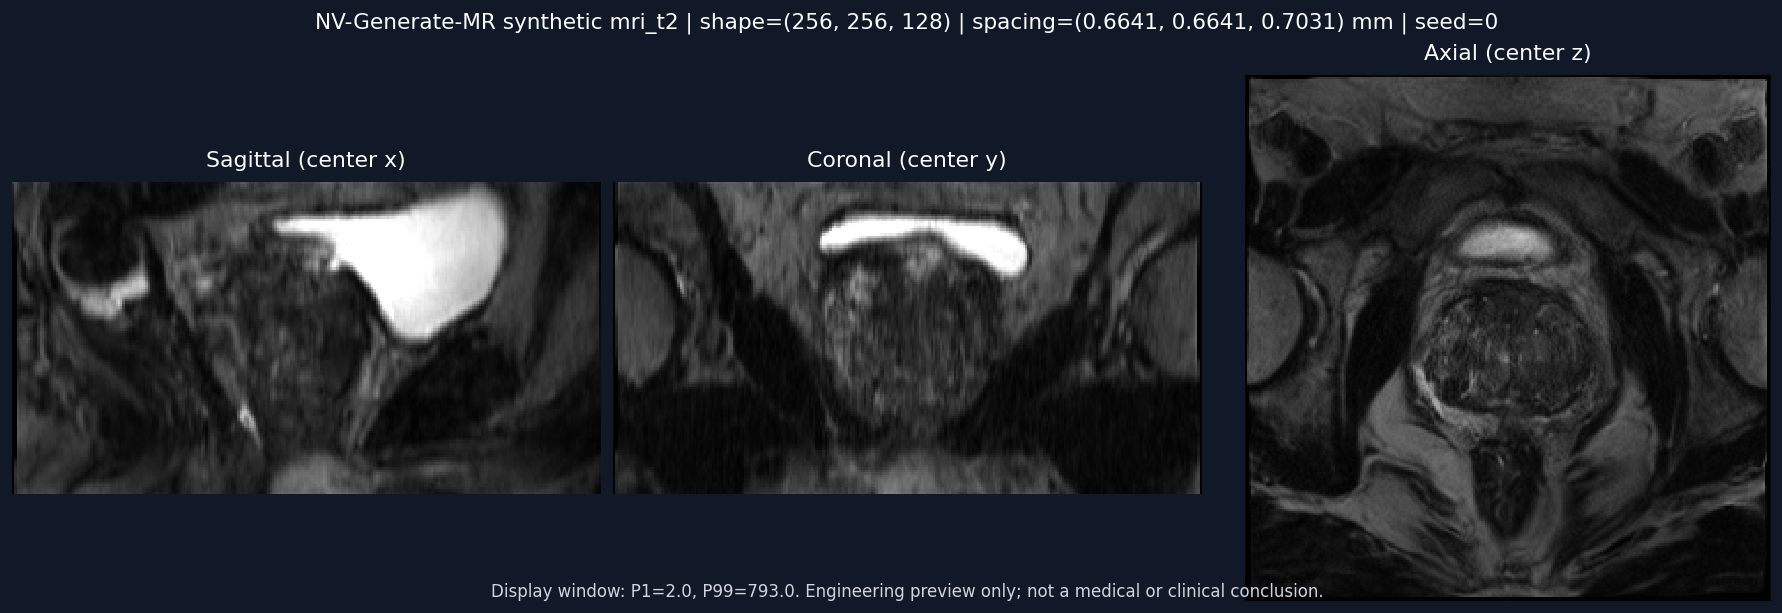

In [7]:
import matplotlib.pyplot as plt

canonical_image = nib.as_closest_canonical(nib.load(str(GENERATED_PATH)))
canonical_data = canonical_image.get_fdata(dtype=np.float32)
canonical_spacing = tuple(float(v) for v in canonical_image.header.get_zooms()[:3])
finite_values = canonical_data[np.isfinite(canonical_data)]
vmin, vmax = np.percentile(finite_values, (1, 99))
if not vmin < vmax:
    vmin, vmax = float(finite_values.min()), float(finite_values.max())
if not vmin < vmax:
    raise ValueError("显示窗宽退化，无法绘制非恒定切片")

x_mid, y_mid, z_mid = (size // 2 for size in canonical_data.shape)
views = [
    ("Sagittal (center x)", canonical_data[x_mid, :, :].T, canonical_spacing[2] / canonical_spacing[1]),
    ("Coronal (center y)", canonical_data[:, y_mid, :].T, canonical_spacing[2] / canonical_spacing[0]),
    ("Axial (center z)", canonical_data[:, :, z_mid].T, canonical_spacing[1] / canonical_spacing[0]),
]

style = {
    "figure.facecolor": "#111827",
    "axes.facecolor": "#111827",
    "axes.titlecolor": "#F9FAFB",
    "text.color": "#F9FAFB",
    "font.size": 11,
}
with plt.rc_context(style):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)
    for axis, (title, image_slice, aspect) in zip(axes, views):
        axis.imshow(
            image_slice,
            cmap="gray",
            origin="lower",
            vmin=vmin,
            vmax=vmax,
            interpolation="nearest",
            aspect=aspect,
        )
        axis.set_title(title, pad=10)
        axis.set_axis_off()
    fig.suptitle(
        f"NV-Generate-MR synthetic {MODALITY} | shape={canonical_data.shape} | "
        f"spacing={tuple(round(v, 4) for v in canonical_spacing)} mm | seed={RANDOM_SEED}",
        fontsize=13,
    )
    fig.text(
        0.5, 0.01,
        f"Display window: P1={vmin:.1f}, P99={vmax:.1f}. "
        "Engineering preview only; not a medical or clinical conclusion.",
        ha="center", va="bottom", color="#D1D5DB", fontsize=10,
    )
    plt.show()

### 2.4 结果说明

- 显示内容来自模型本次生成的合成 MRI，不是患者图像，也不是对已有 MRI 的变换。
- shape、spacing、finite、nonconstant、nonnegative 和切片预览属于工程检查，不代表医学质量或临床有效性。
- GPU 名称、耗时、显存和图像均来自本 Notebook 的同一次完整执行。

---
本文档仅提供相关软件的配置与使用说明，不包含亦不分发前述软件的源代码或目标代码，且不涉及对其源代码的任何修改。您按照本文档配置、部署或使用相关软件时，应遵守适用许可证规定的条款及条件。相关软件的源代码、许可证全文、版权与归属声明及其他项目文档，请以其官方网站或原始发布页面为准。

Copyright (c) 2026 MetaX Integrated Circuits (Shanghai) Co., Ltd. All rights reserved.